# Exploratory Data Analysis: ClinVar Variant Classifications

### Objective
Visualize the cleaned dataset to understand feature distributions, detect outliers, and uncover relationships between individual features and the target (`class`: Concordant vs Conflicting).

This notebook covers:
- **Univariate analysis:** histograms, boxplots, countplots
- **Bivariate & multivariate analysis:** scatter plots, bar plots, correlation heatmap

### Color Scheme
A single consistent palette is used throughout:
- **Class comparisons** (Concordant vs Conflicting): a fixed blue/orange pair, used identically in every plot that splits by class.
- **Ordered/multi-category plots** (e.g. `impact`): `viridis`.
- **Correlation heatmaps:** `coolwarm`.
- **Plain single-variable plots:** a single teal accent color.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Consistent color scheme used across every plot in this notebook
CLASS_PALETTE = {'Concordant': '#4C72B0', 'Conflicting': '#DD8452'}
SEQUENTIAL_CMAP = 'viridis'
HEATMAP_CMAP = 'coolwarm'
ACCENT_COLOR = '#2A9D8F'
BEFORE_COLOR = '#C44E52'
AFTER_COLOR = ACCENT_COLOR

## Step 1: Loading the Data

This notebook tells a before/after story, so three versions of the data are loaded up front:
- **Raw data** — straight from Kaggle, before any cleaning. Used to measure how bad the missing-values problem actually was.
- **`v1` checkpoint** — saved right after missing-value handling, before redundant columns were dropped. Used to show *why* those columns were dropped.
- **Final cleaned dataset** — the output of `02_data_cleaning.ipynb`. This is what the rest of the notebook (all the univariate and bivariate analysis) actually explores.

In [2]:
df_raw = pd.read_csv('/Users/rghdmajd/PycharmProjects/ClinVar_Project/data/raw/clinvar_conflicting.csv', low_memory=False)
df_v1 = pd.read_csv('/Users/rghdmajd/PycharmProjects/ClinVar_Project/data/processed/cleaned_semi_processedv1.csv', low_memory=False)
df = pd.read_csv('/Users/rghdmajd/PycharmProjects/ClinVar_Project/data/processed/cleaned_semi_processed.csv', low_memory=False)

print("Raw data shape:", df_raw.shape)
print("v1 checkpoint shape:", df_v1.shape)
print("Final cleaned data shape:", df.shape)
df.head()

Raw data shape: (65188, 46)
v1 checkpoint shape: (65188, 31)
Final cleaned data shape: (65188, 30)


,chrom,pos,ref,alt,clnvc,class,allele,consequence,impact,symbol,feature_type,feature,amino_acids,codons,strand,loftool,cadd_phred,missense_variant,5_prime_utr_variant,intron_variant,3_prime_utr_variant,2kb_upstream_variant,synonymous_variant,500b_downstream_variant,splice_donor_variant,frameshift_variant,nonsense,splice_acceptor_variant,clinical_disease_count,mean_af
0,1,1168180,G,C,single_nucleotide_variant,0,C,missense_variant,MODERATE,B3GALT6,Transcript,NM_080605.3,E/D,gaG/gaC,1.0,0.157,1.053,1,0,0,0,0,0,0,0,0,0,0,0,0.094633
1,1,1470752,G,A,single_nucleotide_variant,0,A,missense_variant,MODERATE,TMEM240,Transcript,NM_001114748.1,P/L,cCg/cTg,-1.0,0.157,31.000,1,0,0,0,0,0,0,0,0,0,0,1,0.000000
2,1,1737942,A,G,single_nucleotide_variant,1,G,missense_variant,MODERATE,GNB1,Transcript,NM_002074.4,I/T,aTc/aCc,-1.0,0.157,28.100,1,1,0,0,0,0,0,0,0,0,0,6,0.000003
3,1,2160305,G,A,single_nucleotide_variant,0,A,missense_variant,MODERATE,SKI,Transcript,XM_005244775.1,G/S,Ggc/Agc,1.0,0.157,22.500,1,0,0,0,0,0,0,0,0,0,0,1,0.000000
4,1,2160305,G,T,single_nucleotide_variant,0,T,missense_variant,MODERATE,SKI,Transcript,XM_005244775.1,G/C,Ggc/Tgc,1.0,0.157,24.700,1,0,0,0,0,0,0,0,0,0,0,1,0.000000


## Step 2: Confirming the Cleaning Actually Worked

Before diving into the cleaned dataset, two quick checks against the raw/checkpoint data confirm the cleaning stage (`02_data_cleaning.ipynb`) did what it was supposed to do.

### Missing Values: Before vs After

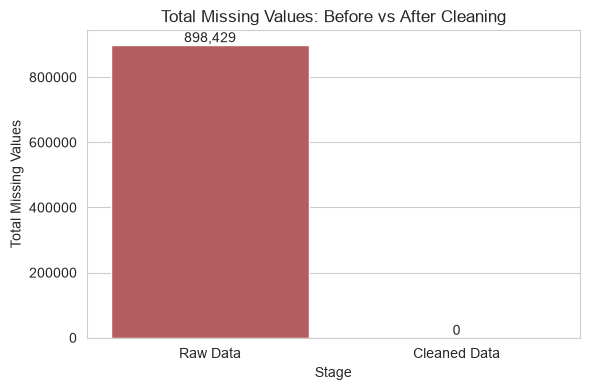

In [3]:
missing_summary = pd.DataFrame({
    'Stage': ['Raw Data', 'Cleaned Data'],
    'Total Missing Values': [df_raw.isnull().sum().sum(), df.isnull().sum().sum()]
})

plt.figure(figsize=(6, 4))
sns.barplot(data=missing_summary, x='Stage', y='Total Missing Values',
            hue='Stage', palette=[BEFORE_COLOR, AFTER_COLOR], legend=False)
plt.title('Total Missing Values: Before vs After Cleaning')
for i, v in enumerate(missing_summary['Total Missing Values']):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Correlation Before Cleaning: Justifying Dropped Features

The `v1` checkpoint still has the raw allele-frequency columns (`AF_ESP`, `AF_EXAC`, `AF_TGP`) and both CADD scores (`CADD_PHRED`, `CADD_RAW`), so it's the right snapshot to show *why* cleaning consolidated/dropped them, before they disappear from the final dataset.

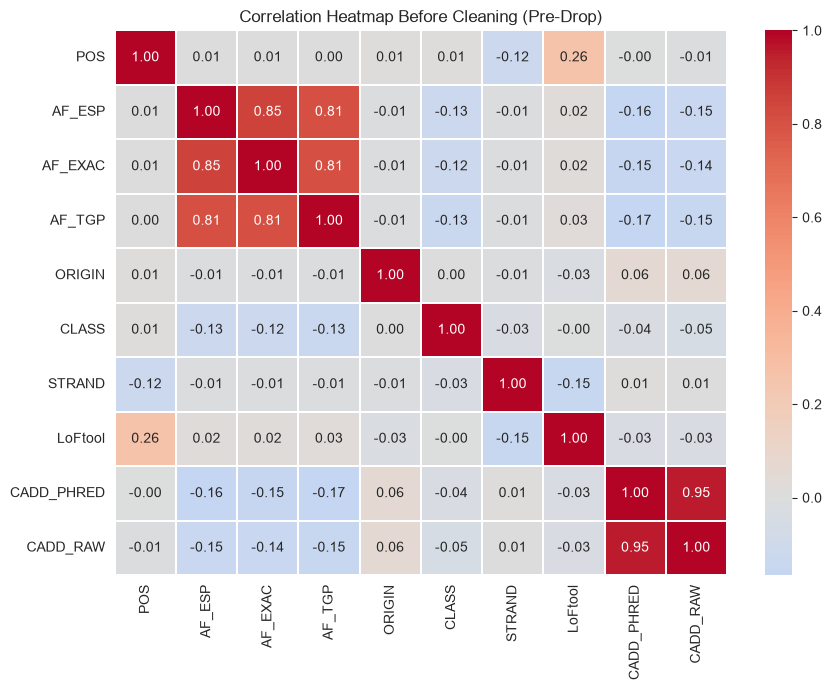

In [4]:
numeric_v1 = df_v1.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_v1.corr(), cmap=HEATMAP_CMAP, center=0, annot=True, fmt='.2f', linewidths=0.3)
plt.title('Correlation Heatmap Before Cleaning (Pre-Drop)')
plt.tight_layout()
plt.show()

**What this justifies:** `AF_ESP`, `AF_EXAC`, and `AF_TGP` are all highly correlated with each other (~0.8+) — they measure the same underlying allele frequency across different population cohorts, so cleaning consolidates them into a single `mean_af` feature instead of keeping three redundant columns. Likewise, `CADD_RAW` and `CADD_PHRED` are almost perfectly correlated (they're the same pathogenicity score on two different scales), so `CADD_RAW` is dropped and `CADD_PHRED` is kept.

In [5]:
# Free up memory now that the raw/checkpoint comparisons are done — everything
# from here on works with the final cleaned `df`.
del df_raw, df_v1, numeric_v1

## Univariate Analysis

### Histograms: Key Numeric Features

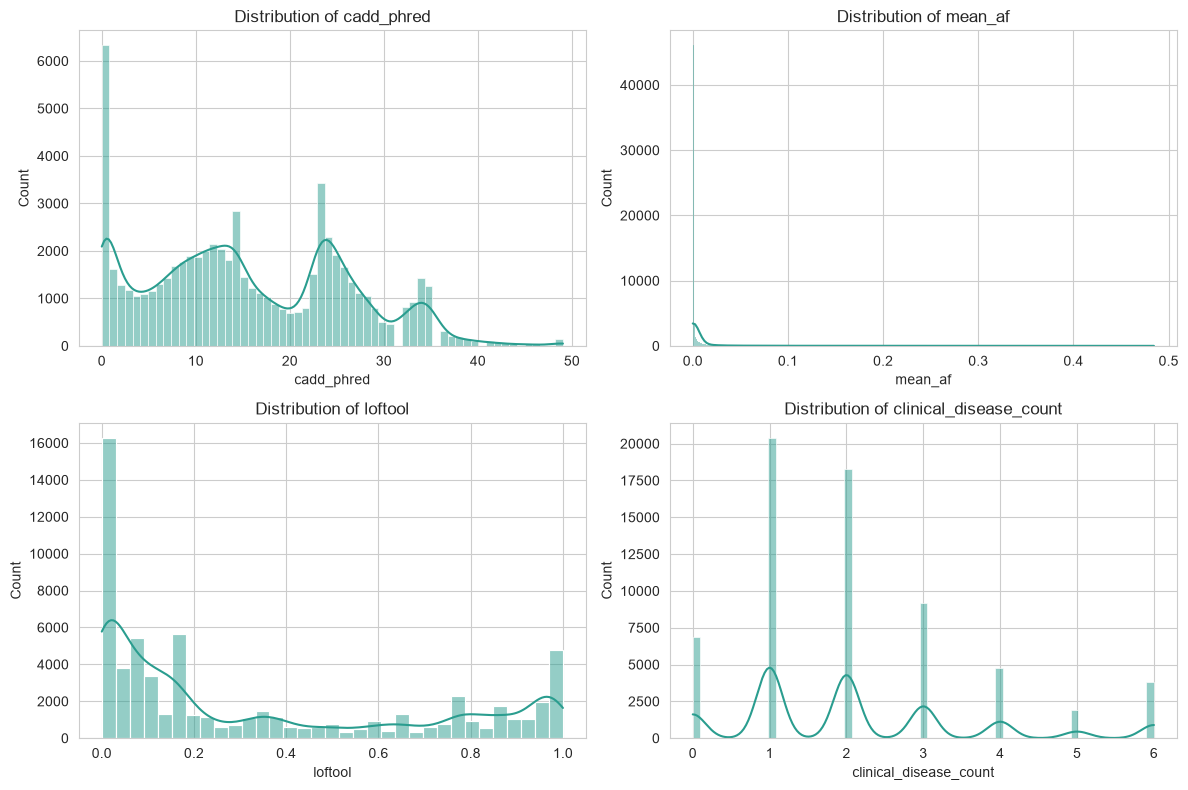

In [6]:
num_features = ['cadd_phred', 'mean_af', 'loftool', 'clinical_disease_count']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color=ACCENT_COLOR)
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

### Boxplots: Outlier Detection

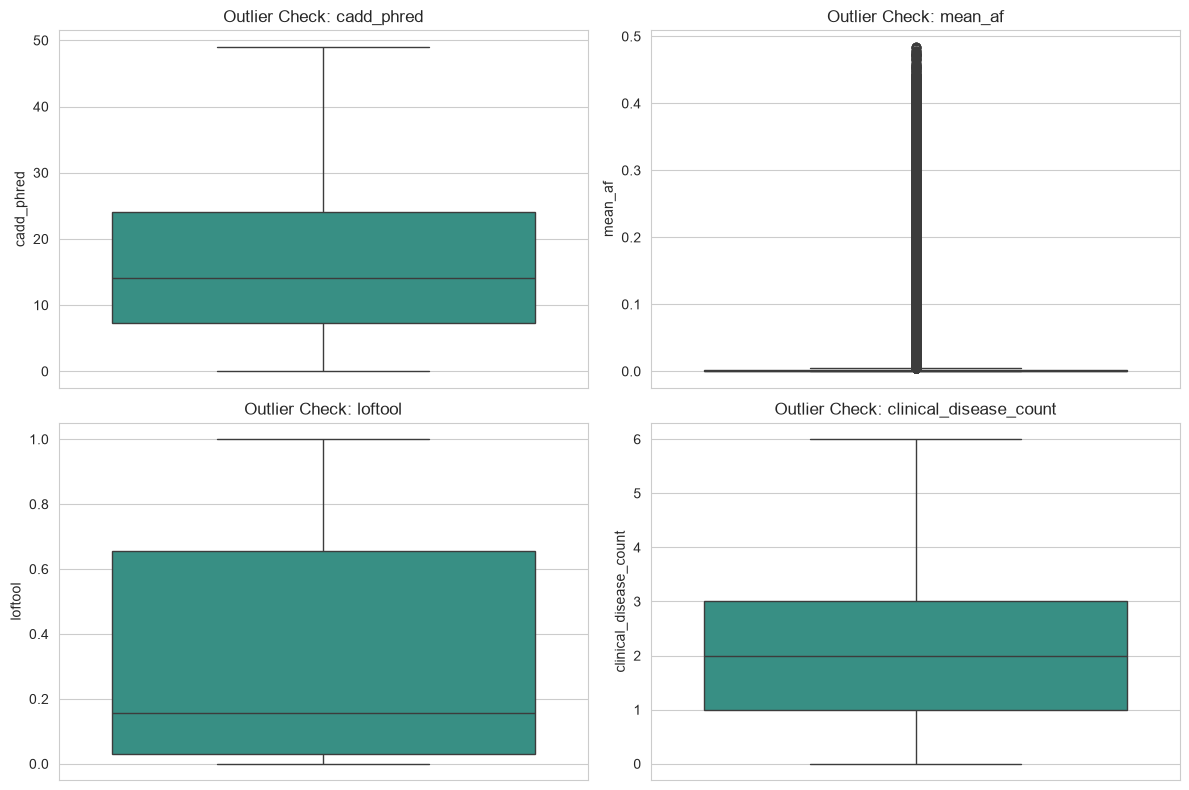

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=df[col], ax=axes[i], color=ACCENT_COLOR)
    axes[i].set_title(f'Outlier Check: {col}')

plt.tight_layout()
plt.show()

### Countplots: Target and Impact Distribution

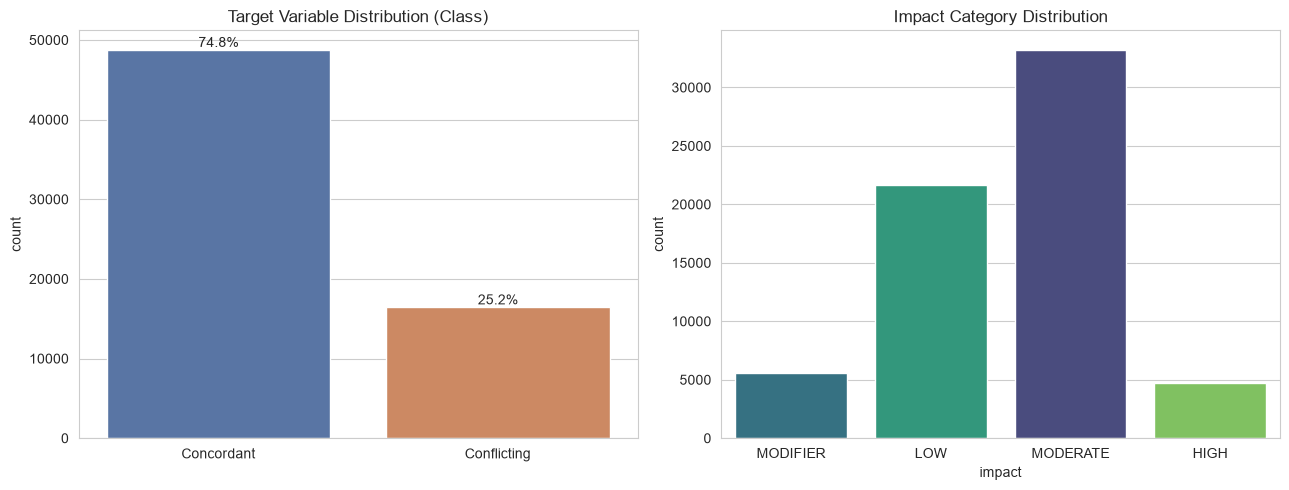

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_plot = df.copy()
df_plot['class_label'] = df_plot['class'].map({0: 'Concordant', 1: 'Conflicting'})

sns.countplot(x='class_label', data=df_plot, hue='class_label', palette=CLASS_PALETTE, legend=False, ax=axes[0])
axes[0].set_title('Target Variable Distribution (Class)')
axes[0].set_xlabel('')
for p in axes[0].patches:
    pct = 100 * p.get_height() / len(df)
    axes[0].annotate(f'{pct:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')

impact_order = ['MODIFIER', 'LOW', 'MODERATE', 'HIGH']
sns.countplot(x='impact', data=df, order=impact_order, hue='impact', palette=SEQUENTIAL_CMAP, legend=False, ax=axes[1])
axes[1].set_title('Impact Category Distribution')

plt.tight_layout()
plt.show()

## Bivariate & Multivariate Analysis

### Correlation Heatmap (After Cleaning)

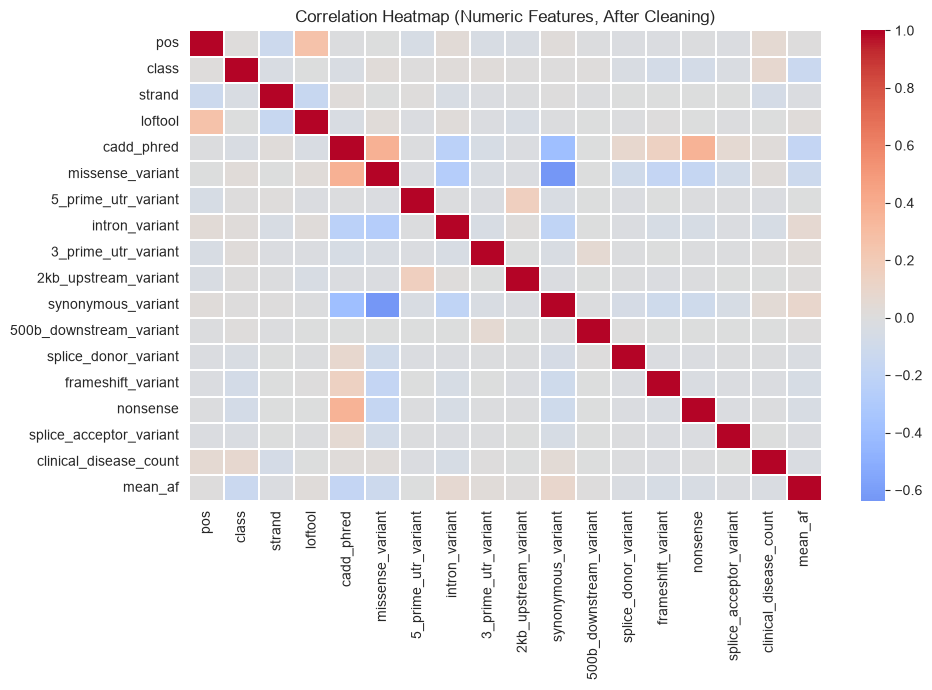

In [9]:
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), cmap=HEATMAP_CMAP, center=0, linewidths=0.3)
plt.title('Correlation Heatmap (Numeric Features, After Cleaning)')
plt.tight_layout()
plt.show()

### Boxplots by Class: Do Key Features Differ Between Concordant and Conflicting Variants?

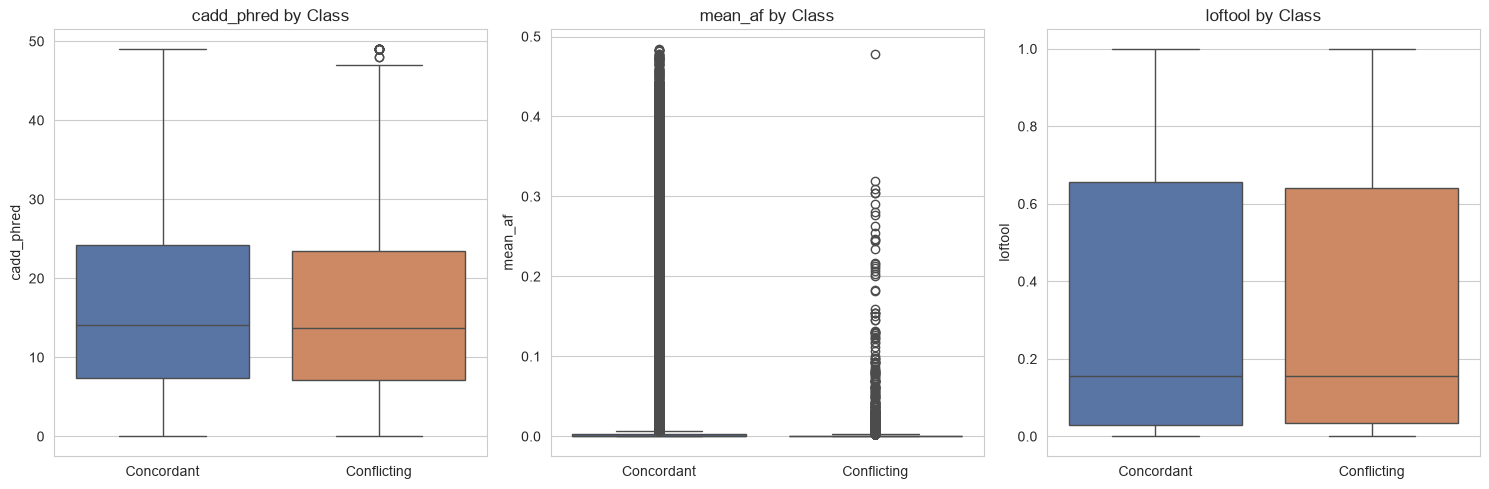

In [10]:
df_plot = df.copy()
df_plot['class_label'] = df_plot['class'].map({0: 'Concordant', 1: 'Conflicting'})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['cadd_phred', 'mean_af', 'loftool']):
    sns.boxplot(x='class_label', y=col, data=df_plot, hue='class_label', palette=CLASS_PALETTE, legend=False, ax=axes[i])
    axes[i].set_title(f'{col} by Class')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### Bar Plot: Average CADD Score by Impact Category

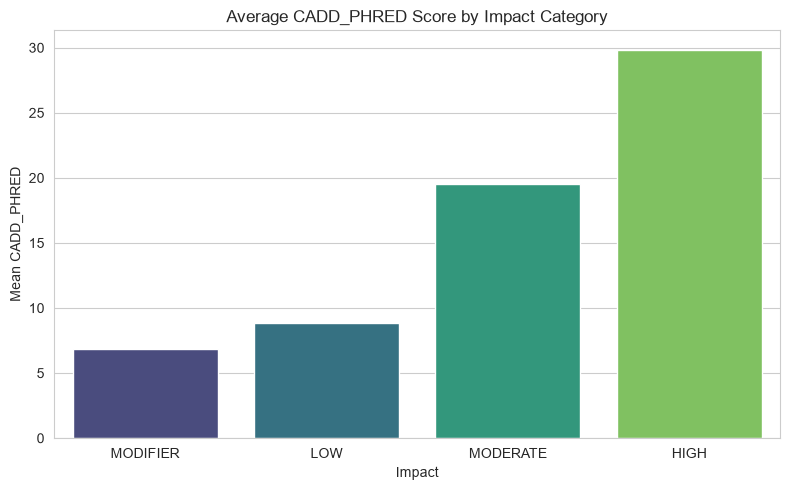

In [11]:
plt.figure(figsize=(8, 5))
avg_cadd = df.groupby('impact')['cadd_phred'].mean().reindex(impact_order)
sns.barplot(x=avg_cadd.index, y=avg_cadd.values, hue=avg_cadd.index, palette=SEQUENTIAL_CMAP, legend=False)
plt.title('Average CADD_PHRED Score by Impact Category')
plt.ylabel('Mean CADD_PHRED')
plt.xlabel('Impact')
plt.tight_layout()
plt.show()

### Scatter Plot: CADD Score vs Mean Allele Frequency by Class

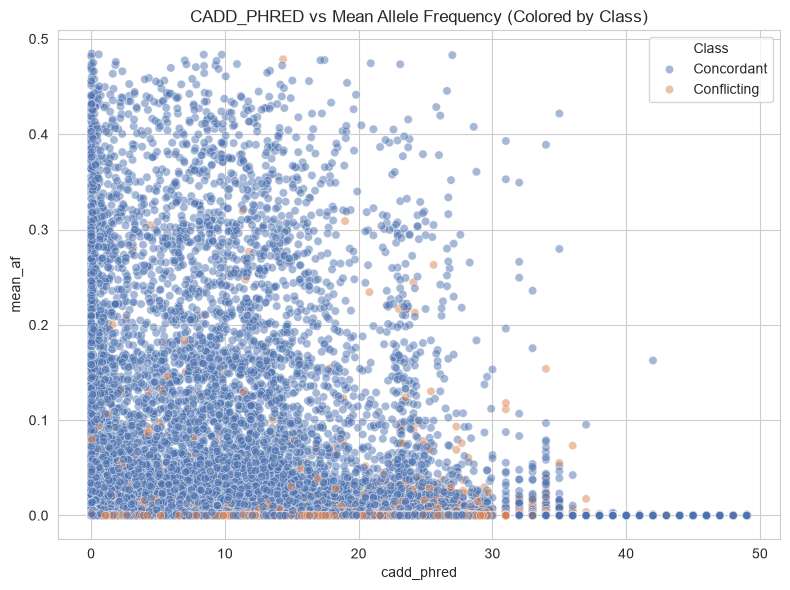

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='cadd_phred', y='mean_af', hue=df['class'].map({0: 'Concordant', 1: 'Conflicting'}),
                data=df, alpha=0.5, palette=CLASS_PALETTE)
plt.title('CADD_PHRED vs Mean Allele Frequency (Colored by Class)')
plt.legend(title='Class')
plt.tight_layout()
plt.show()

## Key Insights

1. **Why columns were dropped:** the pre-cleaning correlation heatmap shows `AF_ESP`/`AF_EXAC`/`AF_TGP` and `CADD_RAW`/`CADD_PHRED` are near-duplicate signals — this is the concrete evidence behind consolidating/dropping them during cleaning.
2. **Cleaning impact:** the raw dataset had 898,429 missing values in total; the cleaned dataset has zero.
3. **Class imbalance:** the target confirms the ~75% Concordant / ~25% Conflicting split identified during initial exploration — this is why modeling uses `class_weight='balanced'` rather than plain accuracy-driven training.
4. **CADD score and impact:** average CADD_PHRED score increases with variant impact severity (MODIFIER -> LOW -> MODERATE -> HIGH), matching biological expectation that higher-impact variants tend to be scored as more damaging.
5. **CADD/frequency relationship with class:** conflicting variants (class 1) tend to skew toward higher CADD_PHRED scores and lower allele frequencies than concordant ones, consistent with the Random Forest's feature importance ranking in the modeling notebook.
6. **Outliers:** `mean_af` and `cadd_phred` show a long right tail, expected for allele frequency and pathogenicity scores rather than a data quality issue — `cadd_phred`'s extreme values are capped during cleaning, while `mean_af`'s are preserved and log-transformed only for modeling, since they carry real predictive signal.